# V3 Retraining for Selected Models (0, 2, 3)

This notebook:
1. Reads the V2 comparison metrics file.
2. Selects model indices 0, 2, and 3 after sorting by SMAPE then MAE.
3. Retrains those models on `LGBM_XGB_7_V3` (train+val) and evaluates on test.
4. Plots model-vs-model comparisons on V3.
5. Builds a table comparing V2 metrics vs V3 metrics for the same selected models.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
RANDOM_SEED = 42

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [2]:
# Paths
ROOT = Path('..')
DATA_DIR = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
REPORTS_DIR = ROOT / 'artifacts' / 'reports'

TRAIN_PATH = DATA_DIR / 'train.csv'
VAL_PATH = DATA_DIR / 'val.csv'
TEST_PATH = DATA_DIR / 'test.csv'

# Prefer updated file when present
V2_METRICS_PATH = REPORTS_DIR / 'metrics_test_all_4combos_v1_v2_updated.csv'
if not V2_METRICS_PATH.exists():
    V2_METRICS_PATH = REPORTS_DIR / 'metrics_test_all_4combos_v1_v2.csv'

print('Using V3 data from:', DATA_DIR)
print('Using V2 metrics file:', V2_METRICS_PATH)

Using V3 data from: ..\data\processed\LGBM_XGB_7_V3
Using V2 metrics file: ..\artifacts\reports\metrics_test_all_4combos_v1_v2_updated.csv


In [3]:
# Load V3 splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'cols': [train_df.shape[1], val_df.shape[1], test_df.shape[1]],
    'null_cells': [int(train_df.isna().sum().sum()), int(val_df.isna().sum().sum()), int(test_df.isna().sum().sum())]
})

,split,rows,cols,null_cells
0,train,68976,34,0
1,val,14370,34,0
2,test,15807,34,0


In [4]:
# Feature schema for V3: V2 schema + snap_relevant
target_col = 'aggregated_sales_7'
categorical_features = ['item_id']
numeric_features = [
    'is_month_end',
    'sales_lag_7',
    'sales_roll_mean_7',
    'aggregated_sell_price',
    'discount_depth',
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_4',
    'sales_roll_mean_2',
    'sales_roll_mean_4',
    'sales_roll_std_4',
    'price_lag_1',
    'price_change_bucket',
    'item_mean_train',
    'item_std_train',
    'item_cv_train',
    'weeks_since_first_seen',
    'snap_relevant',
]
event_features = [
    'event_christmas_7',
    'event_easter_7',
    'event_eid_al_fitr_7',
    'event_eid_al_adha_7',
    'event_fathers_day_7',
    'event_halloween_7',
    'event_mothers_day_7',
    'event_newyear_7',
    'event_orthodox_christmas_7',
    'event_orthodox_easter_7',
    'event_ramadan_starts_7',
    'event_thanksgiving_7',
    'event_valentines_day_7',
]

feature_cols = categorical_features + numeric_features + event_features

missing = sorted(set(feature_cols + [target_col, 'date']) - set(train_df.columns))
if missing:
    raise ValueError(f'Missing required columns in V3 train set: {missing}')

print('Feature count:', len(feature_cols))

Feature count: 32


In [5]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps))

def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(y_pred - y_true))

def evaluate(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'SMAPE': float(smape(y_true, y_pred)),
        'BIAS': float(bias(y_true, y_pred)),
    }

def build_model(kind):
    prep = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features + event_features),
        ],
        remainder='drop'
    )

    if kind == 'base_lgbm':
        reg = LGBMRegressor(
            random_state=RANDOM_SEED,
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
        )
    elif kind == 'base_xgb':
        reg = XGBRegressor(
            random_state=RANDOM_SEED,
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            n_jobs=-1,
        )
    elif kind == 'ch_lgbm':
        reg = LGBMRegressor(
            random_state=RANDOM_SEED,
            n_estimators=900,
            learning_rate=0.03,
            num_leaves=63,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.10,
            reg_lambda=0.60,
        )
    elif kind == 'ch_xgb':
        reg = XGBRegressor(
            random_state=RANDOM_SEED,
            n_estimators=900,
            learning_rate=0.03,
            max_depth=8,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.10,
            reg_lambda=1.00,
            objective='reg:squarederror',
            n_jobs=-1,
        )
    else:
        raise ValueError(f'Unknown model kind: {kind}')

    return Pipeline(steps=[('prep', prep), ('model', reg)])

def parse_model_to_spec(model_name):
    if model_name == 'LightGBM':
        return {'kind': 'single', 'single_kind': 'base_lgbm', 'label': 'LightGBM'}
    if model_name == 'XGBoost':
        return {'kind': 'single', 'single_kind': 'base_xgb', 'label': 'XGBoost'}
    if model_name == 'ChallengerLGBM':
        return {'kind': 'single', 'single_kind': 'ch_lgbm', 'label': 'ChallengerLGBM'}
    if model_name == 'ChallengerXGBoost':
        return {'kind': 'single', 'single_kind': 'ch_xgb', 'label': 'ChallengerXGBoost'}

    if model_name.startswith('ChallengerBlend_LGBM_XGB_w'):
        m = re.search(r'w([0-9]+\.[0-9]+)$', model_name)
        if m is None:
            raise ValueError(f'Cannot parse blend weight from model name: {model_name}')
        w = float(m.group(1))
        return {'kind': 'blend', 'w': w, 'left_kind': 'ch_lgbm', 'right_kind': 'ch_xgb', 'label': model_name}

    raise ValueError(f'Unsupported selected model name: {model_name}')

In [6]:
# Select models 0, 2, 3 from V2 ranking
v2_metrics = pd.read_csv(V2_METRICS_PATH)

required_cols = ['dataset', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS', 'VA_MAE_pct', 'VA_SMAPE_pct']
missing_cols = [c for c in required_cols if c not in v2_metrics.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in metrics file: {missing_cols}')

ranked = v2_metrics[required_cols].copy().sort_values(['SMAPE', 'MAE'], ascending=[True, True]).reset_index(drop=True)
selected_idx = [0, 2, 3]
selected_v2 = ranked.iloc[selected_idx].copy()
selected_v2['selected_index'] = selected_idx

selected_v2[['selected_index', 'dataset', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS']]

,selected_index,dataset,model,MAE,RMSE,SMAPE,BIAS
0,0,CHALLENGER_V2,ChallengerXGBoost,4.948366,9.845082,64.726573,1.130468
2,2,CHALLENGER_V2,ChallengerBlend_LGBM_XGB_w0.85,4.925753,9.749072,64.740418,1.120619
3,3,LGBM_XGB_7_V2,LightGBM,4.896295,9.800620,65.117957,0.919454


In [7]:
# Train selected models on V3 (train+val), evaluate on V3 test
pretest_df = pd.concat([train_df, val_df], ignore_index=True).copy()
X_pre = pretest_df[feature_cols].copy()
y_pre = pretest_df[target_col].astype(float).copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(float).copy()

rows_v3 = []
pred_store = {}

for _, r in selected_v2.iterrows():
    spec = parse_model_to_spec(r['model'])

    if spec['kind'] == 'single':
        mdl = build_model(spec['single_kind'])
        mdl.fit(X_pre, y_pre)
        pred = mdl.predict(X_test)
    else:
        mdl_left = build_model(spec['left_kind'])
        mdl_right = build_model(spec['right_kind'])
        mdl_left.fit(X_pre, y_pre)
        mdl_right.fit(X_pre, y_pre)
        pred_left = mdl_left.predict(X_test)
        pred_right = mdl_right.predict(X_test)
        pred = spec['w'] * pred_right + (1.0 - spec['w']) * pred_left

    m = evaluate(y_test.values, pred)
    m.update({
        'selected_index': int(r['selected_index']),
        'dataset_v2': r['dataset'],
        'model': r['model'],
    })
    rows_v3.append(m)
    pred_store[r['model']] = pred

v3_metrics = pd.DataFrame(rows_v3).sort_values('selected_index').reset_index(drop=True)
v3_metrics[['selected_index', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS']]

  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6510
[LightGBM] [Info] Number of data points in the train set: 83346, number of used features: 1468
[LightGBM] [Info] Start training from score 14.027932
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6510
[LightGBM] [Info] Number of data points in the train set: 83346, number of used features: 1468
[LightGBM] [Info] Start training from score 14.027932


,selected_index,model,MAE,RMSE,SMAPE,BIAS
0,0,ChallengerXGBoost,4.830644,9.675082,64.658911,0.717612
1,2,ChallengerBlend_LGBM_XGB_w0.85,4.815653,9.608785,64.662705,0.717518
2,3,LightGBM,4.800202,9.728443,65.111435,0.477117


In [8]:
# Comparison table: V2 vs V3 for selected models
v2_sel = selected_v2[['selected_index', 'dataset', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS']].copy()
v2_sel = v2_sel.rename(columns={
    'dataset': 'dataset_v2',
    'MAE': 'MAE_v2',
    'RMSE': 'RMSE_v2',
    'SMAPE': 'SMAPE_v2',
    'BIAS': 'BIAS_v2',
})

v3_sel = v3_metrics[['selected_index', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS']].copy()
v3_sel = v3_sel.rename(columns={
    'MAE': 'MAE_v3',
    'RMSE': 'RMSE_v3',
    'SMAPE': 'SMAPE_v3',
    'BIAS': 'BIAS_v3',
})

comparison = v2_sel.merge(v3_sel, on=['selected_index', 'model'], how='inner')
comparison['dSMAPE_v3_minus_v2'] = comparison['SMAPE_v3'] - comparison['SMAPE_v2']
comparison['dMAE_v3_minus_v2'] = comparison['MAE_v3'] - comparison['MAE_v2']
comparison['dRMSE_v3_minus_v2'] = comparison['RMSE_v3'] - comparison['RMSE_v2']
comparison['dBIAS_v3_minus_v2'] = comparison['BIAS_v3'] - comparison['BIAS_v2']

comparison = comparison.sort_values('selected_index').reset_index(drop=True)
comparison

,selected_index,dataset_v2,model,MAE_v2,RMSE_v2,SMAPE_v2,BIAS_v2,MAE_v3,RMSE_v3,SMAPE_v3,BIAS_v3,dSMAPE_v3_minus_v2,dMAE_v3_minus_v2,dRMSE_v3_minus_v2,dBIAS_v3_minus_v2
0,0,CHALLENGER_V2,ChallengerXGBoost,4.948366,9.845082,64.726573,1.130468,4.830644,9.675082,64.658911,0.717612,-0.067662,-0.117721,-0.170000,-0.412856
1,2,CHALLENGER_V2,ChallengerBlend_LGBM_XGB_w0.85,4.925753,9.749072,64.740418,1.120619,4.815653,9.608785,64.662705,0.717518,-0.077713,-0.110100,-0.140287,-0.403101
2,3,LGBM_XGB_7_V2,LightGBM,4.896295,9.800620,65.117957,0.919454,4.800202,9.728443,65.111435,0.477117,-0.006523,-0.096093,-0.072177,-0.442337


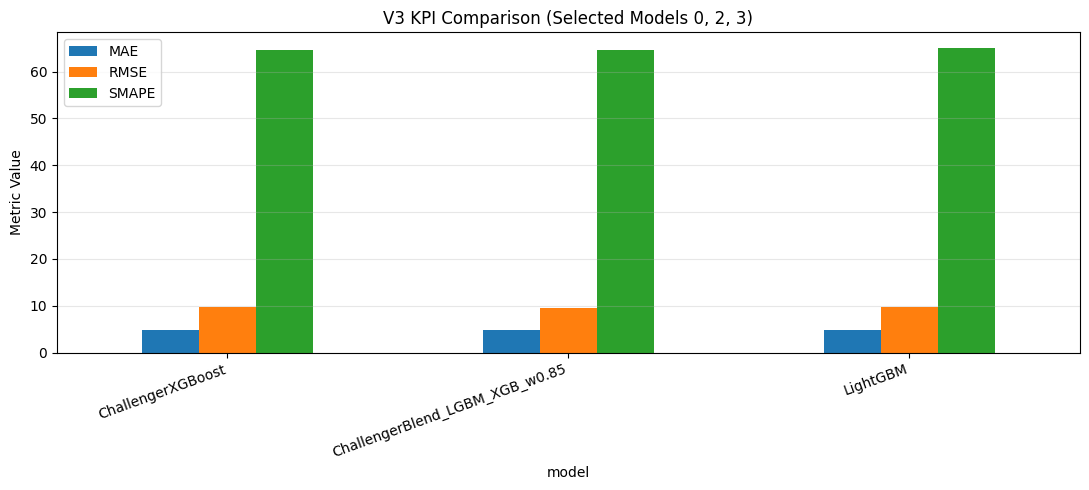

In [9]:
# Plot 1: KPI bars for selected models on V3
plot_df = v3_metrics[['model', 'MAE', 'RMSE', 'SMAPE']].set_index('model')
ax = plot_df.plot(kind='bar', figsize=(11, 5))
ax.set_title('V3 KPI Comparison (Selected Models 0, 2, 3)')
ax.set_ylabel('Metric Value')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

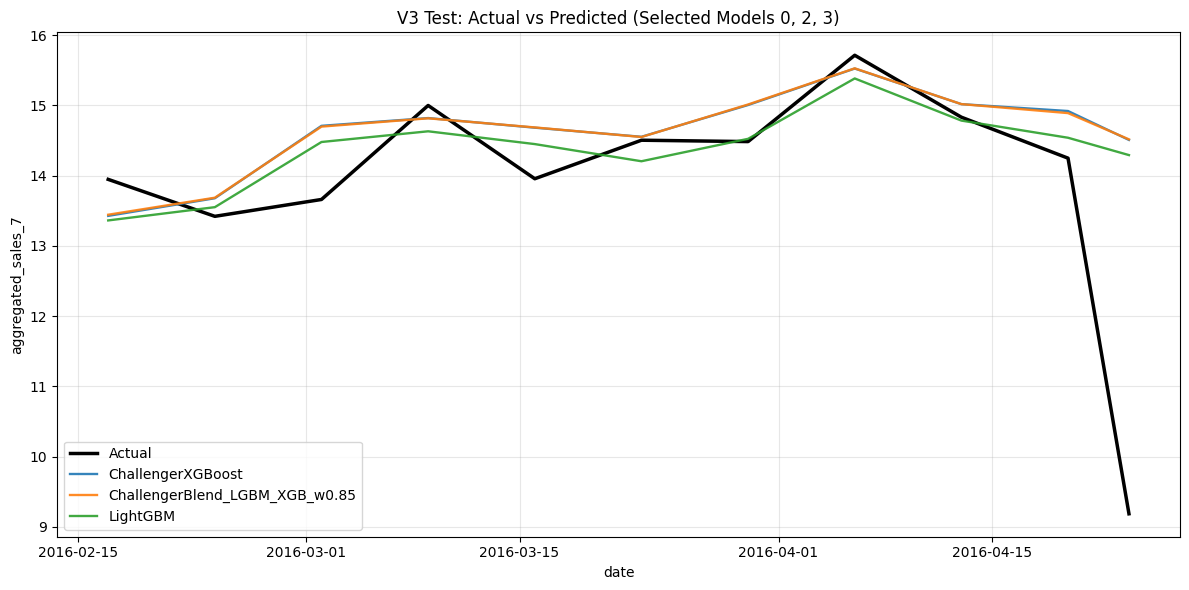

In [10]:
# Plot 2: Actual vs predicted curves (aggregated by date)
curve = test_df[['date', target_col]].copy()
curve = curve.groupby('date', as_index=False)[target_col].mean().rename(columns={target_col: 'actual'})

for model_name, pred in pred_store.items():
    tmp = test_df[['date']].copy()
    tmp['pred'] = pred
    tmp = tmp.groupby('date', as_index=False)['pred'].mean().rename(columns={'pred': model_name})
    curve = curve.merge(tmp, on='date', how='left')

plt.figure(figsize=(12, 6))
plt.plot(curve['date'], curve['actual'], color='black', linewidth=2.5, label='Actual')
for model_name in pred_store.keys():
    plt.plot(curve['date'], curve[model_name], linewidth=1.7, alpha=0.9, label=model_name)

plt.title('V3 Test: Actual vs Predicted (Selected Models 0, 2, 3)')
plt.xlabel('date')
plt.ylabel('aggregated_sales_7')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

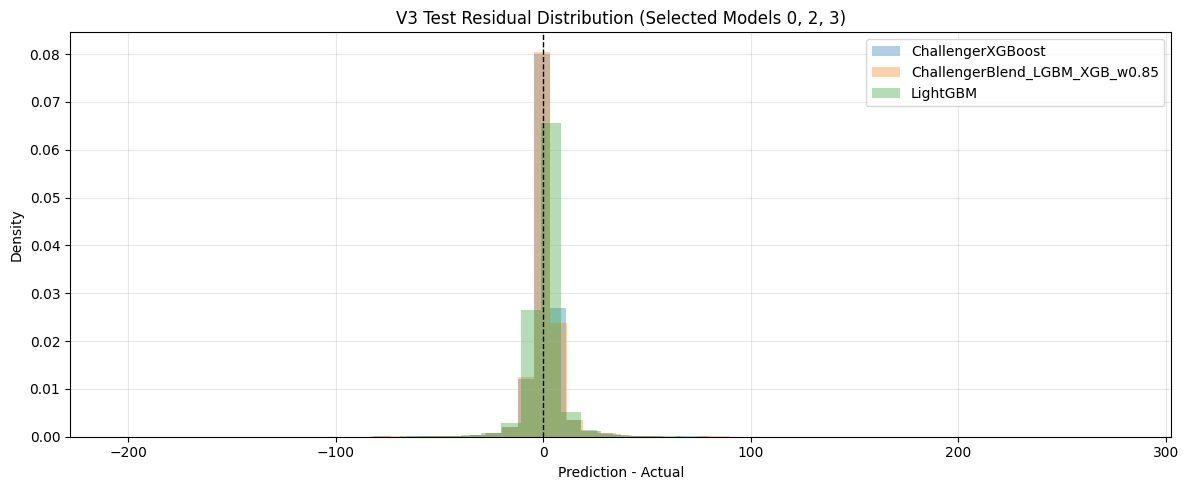

In [11]:
# Plot 3: Residual distributions on V3 test
plt.figure(figsize=(12, 5))
for model_name, pred in pred_store.items():
    residual = pred - y_test.values
    plt.hist(residual, bins=50, alpha=0.35, density=True, label=model_name)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('V3 Test Residual Distribution (Selected Models 0, 2, 3)')
plt.xlabel('Prediction - Actual')
plt.ylabel('Density')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Optional save
out_table = REPORTS_DIR / 'metrics_selected_0_2_3_v2_vs_v3.csv'
comparison.to_csv(out_table, index=False)
print('Saved comparison table:', out_table)

Saved comparison table: ..\artifacts\reports\metrics_selected_0_2_3_v2_vs_v3.csv
